# S9-2 バタフライ取引の構築とPnL分解

## 学習目標

- カーブの曲率（curvature）を取るバタフライ取引を、DV01ニュートラルに構築できる
- 50-50・リスクウェイト・PCAウェイトの3方式が「何をニュートラル化するか」を数式で対比できる
- 実現損益（PnL）をキャリー・ロール・カーブ変化・コンベクシティへ要因分解する恒等式を導ける
- 分解PnLの合計が実PnLと一致すること（説明率 > 95%）を検証できる
- 合成米国債パーカーブから日次でゼロカーブを構築し、2-5-10バタフライをロールしたときの累積PnLとシャープレシオをバックテストできる

## 実務での位置づけ（ファンドはどう稼ぐか）

バタフライは、RV ファンドがカーブの曲率（curvature）だけを取りにいくときの標準的な建て方です。docs/債券ファンドの業務.md の相対価値の分類でいう「イールドカーブ取引」の一種で、レベル（平行移動）にもスロープ（傾き）にも賭けず、$\mathrm{fly}=2y_5-y_2-y_{10}$ というベリーの割高・割安だけを純化して取ります。ファンドの典型的な使い方は、ベリーが過度に cheap（fly が広がりすぎ）と判断すればボディを買ってウィングを売り、fly が平常水準へ収束する方に賭ける、あるいは fly が特定の水準から発散すると読めばその方向に張る、というものです。方向観そのものではなく「カーブの形の歪みが正常化する」ことに賭けるので、金利が上下どちらに動いてもレベルとスロープの損益はニュートラル化され、曲率の収束・発散だけが手元に残ります。

3方式の違いは、そのまま「何のリスクを消して稼ぐか」の設計思想の違いです。50-50 は平行移動しか消せずスロープが残るので、実際にはスロープ変動が損益に紛れ込みます。リスクウェイトは回帰で測ったスロープまで消し、PCA ウェイトは PC1（レベル）と PC2（スロープ）を厳密に相殺して PC3（曲率）だけを残します。ファンドが PCA 建てを好むのは、日々のカーブ変動の大半を占める上位2因子を確実に落とし、狙った曲率シグナルの純度を上げるためです。純度が低いバタフライは、fly が読み通り収束しても別因子の逆風で損益が消える——つまりアルファがノイズに埋もれるので、ウェイト設計は収益を守る工程そのものになります。

このトレードもレバレッジと保有期間で稼ぎ方が決まります。DV01 中立に組んだバタフライは自己資本に対する感応度が小さいので、意味のあるリターンを出すには名目を大きく取り、レポでファンディングします。保有中は各レッグのキャリーとロールが積み上がるため、収束を待つ間の時間損益（fly を建てたときのキャリー＋ロールの符号）が勝敗を分けます。曲率の収束が読み通りでも、負のキャリーを払い続けるバタフライは待つほど削られるため、エントリー時に「収束シナリオの期待値」と「保有中のキャリー」を同じ天秤に載せて判断します。

PnL を キャリー・ロール・カーブ変化・コンベクシティへ分解し、その合計が実 PnL を 95% 超で説明できることを確認する作業は、ファンドにとって収益の品質保証です。説明率が低ければ、想定していない因子（消し損ねたスロープ、モデル外の動き）で損益が出ている証拠で、「たまたま勝った／負けた」ポジションを再現性のあるアルファと取り違えるのを防ぎます。分解が合うことを確認して初めて、その建て方を資金を増やして繰り返す判断ができます。


## 理論

### バタフライ取引とは

バタフライ（butterfly）は、カーブ上の3点を使い、両端（ウィング, wings）と
中央（ボディ／ベリー, body/belly）を反対方向に建てる取引です。2-5-10 バタ
フライなら、2年・10年をウィング、5年をボディとします。ボディを買い（ロング）、
ウィングを売る（ショート）ポジションは「ベリーのリッチ化に賭ける」取引で、
カーブの**曲率**に対する感応度だけを残すよう設計します。

バタフライ・スプレッド（曲率の代理変数）は次で定義します。

$$ \mathrm{fly} = 2 y_5 - y_2 - y_{10} $$

$y_2, y_5, y_{10}$ が同じだけ平行に動いても（レベル変化）$\mathrm{fly}$ は不変、
2年と10年が逆に動いても（スロープ変化）不変で、ベリーだけが動く**曲率変化**に
対してのみ反応します。取引もこの性質を持つように重みを決めます。

### DV01ニュートラル構築

各レッグ $i$ の **DV01**（1bp の利回り変化に対する価格変化額、ここでは絶対値）
を $D_i$、建玉のドル建て符号付き DV01 を $w_i$（ロングで正）とします。利回りが
$\Delta y_i$（bp）動いたときのポジション損益は一次近似で

$$ \mathrm{PnL} \approx -\sum_i w_i \, \Delta y_i $$

です。ここで **平行移動**（すべての $\Delta y_i$ が等しい）に対して損益がゼロ、
すなわち

$$ \sum_i w_i = w_2 + w_5 + w_{10} = 0 $$

を満たすとき、この取引は **DV01ニュートラル**（parallel-neutral）です。これが
バタフライ構築の第一の条件です。ボディの DV01 を $w_5 = -B$（ショート）に固定
すると、ウィングは合計 $+B$ を分担します。残る自由度は「$+B$ を2年と10年へ
どう配分するか」だけで、3方式はこの配分ルールが異なります。

### 3方式が「何をニュートラル化するか」

一般に、カーブの動きを因子 $f$（テナー別ローディング $\mathbf{l}^{(f)}=(l_2,l_5,l_{10})$、
スコア $s_f$）で表すと $\Delta y_i = l_i^{(f)} s_f$ なので、因子 $f$ による損益は

$$ \mathrm{PnL}_f = -\Big(\sum_i w_i l_i^{(f)}\Big) s_f = -(\mathbf{w}\cdot\mathbf{l}^{(f)})\, s_f $$

よって **因子 $f$ にニュートラル $\iff \mathbf{w}\cdot\mathbf{l}^{(f)}=0$** です。

| 方式 | ウィング配分 | ニュートラル化する対象 | 残る感応度 |
|---|---|---|---|
| 50-50 | $w_2=w_{10}=B/2$ | 平行移動 $\mathbf{l}=(1,1,1)$ のみ | スロープ・曲率 |
| リスクウェイト | ベータ比 $w_2\!\propto\!\beta_2,\ w_{10}\!\propto\!\beta_{10}$ | 平行移動＋（回帰で測った）スロープ | 曲率 |
| PCAウェイト | PC1・PC2 を消すよう連立で解く | PC1（レベル）と PC2（スロープ）を厳密に | PC3（曲率）のみ |

- **50-50**：$w_2=w_{10}=B/2,\ w_5=-B$。$\sum w_i=0$ なので平行移動には
  ニュートラルですが、$(1,-?,?)$ のスロープには $\mathbf{w}\cdot(l_2,l_5,l_{10})\neq0$
  で反応します。最も素朴で、実務では「まずこれ」という基準形です。
- **リスクウェイト**：ベリーの利回り変化をウィングへ回帰した
  $\Delta y_5 = a + \beta_2 \Delta y_2 + \beta_{10}\Delta y_{10} + \varepsilon$ の
  係数 $\beta_2,\beta_{10}$ を使い、DV01中立を保ちつつウィングの DV01 を
  $\beta$ 比で配分します（$w_2=B\beta_2/(\beta_2+\beta_{10})$ など）。ウィングが
  実際に動く比率でヘッジするので、経験的なスロープに対して頑健です。
- **PCAウェイト**：カーブ変化行列の主成分 $\mathbf{v}^{(1)}$（レベル）と
  $\mathbf{v}^{(2)}$（スロープ）に対して $\mathbf{w}\cdot\mathbf{v}^{(1)}=0,\
  \mathbf{w}\cdot\mathbf{v}^{(2)}=0$ を課し、$w_5=-B$ 固定のもとで $w_2,w_{10}$ を
  $2\times2$ 連立で解きます。PC1・PC2 を構成的に消すので、残るのは PC3（曲率）
  への感応度だけになります。主成分は `bondlab.analytics.pca` を再利用します。

### PnL分解の恒等式導出

各レッグを、額面100・クーポン $c$（建玉時の利回りに固定）・満期テナー $\tau$ の
固定利付債とし、価格関数を $P(y,\tau)$ とします。保有期間 $\Delta t$（年）の後、
テナーは $\tau'=\tau-\Delta t$ に縮み、自レッグの利回りは $y_0$ から $y_1$ へ動きます。
ここで **ロール後利回り** $y_{\mathrm{roll}}=z_t(\tau')$ を「今日のカーブが縮んだ
テナーに与える利回り」と定義します（カーブを固定したまま満期短縮）。すると実損益は
恒等的に3つ＋高次に telescoping 分解できます。

$$
\underbrace{P(y_1,\tau') - P(y_0,\tau)}_{\text{実 PnL}}
= \underbrace{[P(y_0,\tau') - P(y_0,\tau)]}_{\text{キャリー}}
+ \underbrace{[P(y_{\mathrm{roll}},\tau') - P(y_0,\tau')]}_{\text{ロール}}
+ \underbrace{[P(y_1,\tau') - P(y_{\mathrm{roll}},\tau')]}_{\text{カーブ変化}}
$$

- **キャリー（carry）**：利回りを $y_0$ に固定したまま時間だけ進んだ収益。
  クーポン収入と満期短縮に伴うプルの合成で、$\approx c\,\Delta t$。
- **ロール（roll-down）**：カーブを動かさずに、縮んだテナーの利回り
  $y_{\mathrm{roll}}$ へ滑り落ちる価格効果。順イールドなら $y_{\mathrm{roll}}<y_0$ で
  ロングにプラスです。
- **カーブ変化（curve）**：カーブ自体が動いたことによる再評価
  $\Delta y = y_1 - y_{\mathrm{roll}}$。これをさらにデュレーション項とコンベクシティ
  項へ Taylor 展開します。

$$
P(y_1,\tau')-P(y_{\mathrm{roll}},\tau')
= \underbrace{-D_{\mathrm{mod}}\,P\,\Delta y}_{\text{デュレーション}}
+ \underbrace{\tfrac12 C\,P\,\Delta y^2}_{\text{コンベクシティ}}
+ \underbrace{R}_{\text{残差}}
$$

よって最終的な恒等式は

$$
\mathrm{PnL} = \text{キャリー} + \text{ロール} + \text{デュレーション} + \text{コンベクシティ} + R
$$

ここでバタフライ全体は各レッグの分解を建玉で加重した和です。

### 残差 $R$ の理由

前半（キャリー＋ロール＋カーブ変化）は telescoping により**厳密**で残差ゼロです。
残差 $R$ が生じるのは、カーブ変化項を2次までの Taylor で近似したためだけです。
$R = O(\Delta y^3)$（3次以上）に加え、$D_{\mathrm{mod}}, C$ を $y_{\mathrm{roll}}$
周りで評価したことによるクロス項が含まれます。日次のように $\Delta y$ が小さい
場面では $R$ は実 PnL に対して極めて小さく、説明率は 99% を超えます。$\Delta y$ が
大きい（相場急変）ほど $R$ は相対的に膨らみます。

**数値例**：ボディのドルDV01を $B=\$10{,}000/\text{bp}$ とすると、50-50 では $(w_2,w_5,w_{10})=(+5{,}000,\,-10{,}000,\,+5{,}000)$ です。$\sum_i w_i=0$ を満たすので、3年限が一律に1bp動く平行移動には損益中立になります。


**数値例**：$y_2=0.20\%,\ y_5=0.55\%,\ y_{10}=0.85\%$ を代入すると $\mathrm{fly}=2\times0.55-0.20-0.85=+0.05\%=+5$ bp となり、ベリー（5年）がウィングに対してやや cheap に値付けされている状態を表します。


## スクラッチ実装

バタフライのポジション構築器と PnL 分解エンジンを自作します。PCA ウェイトの
主成分抽出のみ `bondlab.analytics.pca` を再利用します。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `par_bond_price(y, tau, c, f, face)` | 利回り, テナー, クーポン, 頻度, 額面 | 価格 | 固定利付債の現在価値（周期割引） |
| `par_bond_risk(y, tau, c, f, face)` | 同上 | dict(price, dv01, mod_dur, conv) | 中心差分で DV01・修正デュレーション・コンベクシティ |
| `par_yield_from_curve(curve, tau, f)` | 割引カーブ, テナー, 頻度 | パー利回り | ゼロカーブから各テナーのパー利回りを復元 |
| `butterfly_weights(D, scheme, ...)` | DV01ベクトル, 方式, ベータ/PCA | dict(w, mult) | 3方式の DV01ニュートラル建玉を構築 |
| `decompose_leg_pnl(y0, y1, yroll, tau, dt, c, risk0)` | 各利回り, テナー, 期間, クーポン, リスク | dict(components) | 1レッグ・1ステップの PnL 要因分解 |
| `backtest_butterfly(panel, tenors, scheme, body_dv01)` | パーカーブ表, テナー, 方式, ボディDV01 | dict(daily, cum, sharpe) | 日次ゼロカーブ構築＋バタフライのロール |

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
from bondlab.curve import bootstrap_par, DiscountCurve
from bondlab.bond import FixedRateBond
from bondlab.analytics import pca, duration_convexity

np.random.seed(0)
BP = 1e-4  # 1 basis point

In [2]:
def par_bond_price(y, tau, c, f=2, face=100.0):
    """固定利付債の周期割引による現在価値。

    満期 tau からクーポン間隔 1/f で遡ってクーポン時点 s_j を作り、周期複利
    (1+y/f)^{-f s_j} で割り引く。tau が非整数でも指数は連続なので、時間経過に
    伴う経過利子（キャリー）が滑らかに反映される。
    """
    m = int(np.floor(tau * f + 1e-9))          # 残存クーポン本数
    ks = np.arange(0, m + 1)
    s = tau - ks / f                            # クーポン時点（満期から遡る）
    s = s[s > 1e-9]
    cpn = c / f * face
    pv = np.sum(cpn * (1.0 + y / f) ** (-f * s))
    pv += face * (1.0 + y / f) ** (-f * tau)    # 満期の額面償還
    return float(pv)


def par_bond_risk(y, tau, c, f=2, face=100.0, h=1e-5):
    """価格・DV01・修正デュレーション・コンベクシティを中心差分で求める。

    dv01 = -dP/dy * 1e-4 （額面100あたり、1bp、正値）
    mod_dur = -(1/P) dP/dy,  conv = (1/P) d^2P/dy^2
    """
    p0 = par_bond_price(y, tau, c, f, face)
    pu = par_bond_price(y + h, tau, c, f, face)
    pd_ = par_bond_price(y - h, tau, c, f, face)
    dpdy = (pu - pd_) / (2 * h)
    d2 = (pu - 2 * p0 + pd_) / (h * h)
    return dict(
        price=p0,
        dv01=-dpdy * BP,
        mod_dur=-dpdy / p0,
        conv=d2 / p0,
    )


def par_yield_from_curve(curve, tau, f=2):
    """ゼロ割引カーブから、テナー tau のパー利回り（=額面価格になるクーポン率）を復元。

        par = f * (1 - DF(tau)) / Σ_k DF(k/f),  k=1..f*tau
    """
    m = int(round(tau * f))
    times = np.arange(1, m + 1) / f
    dfs = curve.discount(times)
    annuity = dfs.sum() / f
    return float((1.0 - curve.discount(tau)) / annuity)

自作の価格・リスク関数を、既存の `bondlab.analytics.duration_convexity` と
突合しておきます。5年・半年利付のパー債について、DV01 と修正デュレーションが
一致すれば実装は信頼できます。

In [3]:
import datetime as _dt

_c = 0.04
_bond = FixedRateBond(
    issue=_dt.date(2026, 1, 2),
    maturity=_dt.date(2031, 1, 2),
    coupon=_c,
    frequency=2,
)
_ref = duration_convexity(_bond, ytm=_c, settlement=_dt.date(2026, 1, 2))
_mine = par_bond_risk(_c, 5.0, _c)
print("            bondlab      自作")
print(f"DV01     {_ref['dv01']:.6f}   {_mine['dv01']:.6f}")
print(f"mod dur  {_ref['modified']:.6f}   {_mine['mod_dur']:.6f}")
assert abs(_ref["dv01"] - _mine["dv01"]) < 1e-4
assert abs(_ref["modified"] - _mine["mod_dur"]) < 1e-3
print("突合 OK：自作リスク関数は bondlab と一致します")

            bondlab      自作
DV01     0.044913   0.044913
mod dur  4.491293   4.491293
突合 OK：自作リスク関数は bondlab と一致します


In [4]:
def butterfly_weights(D, scheme="50-50", betas=None, pca_loadings=None, body_dv01=1e4):
    """3方式のバタフライを DV01ニュートラルに構築する。

    Parameters
    ----------
    D : array (3,)
        各テナー（ウィング前, ボディ, ウィング後）の DV01（単位額面あたり, 正）。
    scheme : {"50-50","risk","pca"}
    betas : array (2,)
        risk 用。ベリーをウィングへ回帰した (beta_front, beta_back)。
    pca_loadings : array (2,3)
        pca 用。PC1・PC2 のテナー別ローディング。
    body_dv01 : float
        ボディに割り当てるドル DV01（B）。ショートなので w5 = -B。

    Returns
    -------
    dict(w, mult)
        w   : 符号付きドル DV01 (3,)
        mult: 建玉倍率 m_i = w_i / D_i（PnL = Σ m_i ΔP_i に使う）
    """
    B = body_dv01
    if scheme == "50-50":
        w = np.array([B / 2, -B, B / 2])
    elif scheme == "risk":
        b2, b10 = betas
        s = b2 + b10
        w = np.array([B * b2 / s, -B, B * b10 / s])
    elif scheme == "pca":
        v1, v2 = pca_loadings
        # w5 = -B 固定、Σ w_i v_i = 0 を PC1,PC2 で。未知 w2,w10 を 2x2 で解く。
        A = np.array([[v1[0], v1[2]], [v2[0], v2[2]]])
        rhs = -(-B) * np.array([v1[1], v2[1]])  # -(w5)*v_body
        w2, w10 = np.linalg.solve(A, rhs)
        w = np.array([w2, -B, w10])
    else:
        raise ValueError(f"未知の scheme: {scheme!r}")
    mult = w / D
    return dict(w=w, mult=mult)


def decompose_leg_pnl(y0, y1, yroll, tau, dt, c, risk_roll):
    """1レッグ・1ステップの PnL を要因分解する（額面100あたり）。

    キャリー・ロール・カーブ変化に telescoping 分解し、カーブ変化を
    デュレーション項＋コンベクシティ項＋残差へ Taylor 展開する。
    """
    taup = tau - dt
    p_start = par_bond_price(y0, tau, c)
    p_carry = par_bond_price(y0, taup, c)          # 利回り固定・時間経過
    p_roll = par_bond_price(yroll, taup, c)        # カーブ固定でロール
    p_end = par_bond_price(y1, taup, c)            # カーブが実際に動いた後

    carry = p_carry - p_start
    roll = p_roll - p_carry
    dy = y1 - yroll
    dur = -risk_roll["mod_dur"] * p_roll * dy
    convex = 0.5 * risk_roll["conv"] * p_roll * dy * dy
    actual = p_end - p_start
    resid = actual - (carry + roll + dur + convex)
    return dict(actual=actual, carry=carry, roll=roll,
                duration=dur, convexity=convex, residual=resid)

## QuantLib検証

本 notebook では QuantLib による突合の代わりに、**PnL分解の合計が実 PnL と
一致すること（説明率 > 95%）を検証と位置づけます**。分解恒等式が正しく実装
されていれば、キャリー・ロール・デュレーション・コンベクシティの合計は残差
$R$（3次以上の Taylor 誤差）を除いて実 PnL に一致します。

まず単一レッグ・単一ステップで、分解の各項を合計すると実 PnL に戻ることを
確認します。合成の利回り変化 $\Delta y$ を大小2通り与え、$\Delta y$ が大きい
ほど残差が増える（PnL分解の恒等式の性質）ことも見ます。

In [5]:
tau, dt, c = 5.0, 5 / 252, 0.040
yroll = 0.0398  # 順イールドを縮んだテナーへロール
r_roll = par_bond_risk(yroll, tau - dt, c)

print(f"{'Δy(bp)':>8} {'実PnL':>10} {'分解合計':>10} {'残差':>12} {'説明率':>8}")
for dy_bp in [2.0, 50.0]:
    y1 = yroll + dy_bp * BP
    dec = decompose_leg_pnl(0.040, y1, yroll, tau, dt, c, r_roll)
    fit = dec["carry"] + dec["roll"] + dec["duration"] + dec["convexity"]
    ratio = 1 - abs(dec["residual"]) / abs(dec["actual"])
    print(f"{dy_bp:8.0f} {dec['actual']:10.5f} {fit:10.5f} {dec['residual']:12.2e} {ratio:8.4f}")

  Δy(bp)       実PnL       分解合計           残差      説明率
       2    0.07861    0.07861    -1.79e-08   1.0000
      50   -2.04292   -2.04265    -2.79e-04   0.9999


小さな $\Delta y$ では残差はほぼ機械精度、大きな $\Delta y$ でも説明率は十分高い
ことが分かります。分解エンジンが恒等式どおり動いていることの確認です。

## 実データ適用

`data/samples/synthetic_ust_par_panel.csv`（date, tenor, par_yield）から、日次で
ゼロカーブを `bondlab.curve.bootstrap_par` で構築します。`bootstrap_par` は
等間隔グリッド（クーポン払込日＝テナー）を前提とするため、生のテナー
（0.5, 1, 2, 3, 5, 7, 10, ...）を**0.5年刻みの等間隔グリッドに線形補間**してから
ブートストラップします。その後 2-5-10 バタフライを過去期間ロールし、累積 PnL と
シャープレシオを求めます。ネットワークは使いません。

In [6]:
def build_curve(par_by_tenor, grid=None, f=2):
    """テナー→パー利回りの対応から、0.5年刻みの等間隔グリッドでゼロカーブを構築。"""
    if grid is None:
        grid = np.arange(0.5, 10.0 + 1e-9, 0.5)
    src_t = np.array(sorted(par_by_tenor))
    src_y = np.array([par_by_tenor[t] for t in src_t])
    par_grid = np.interp(grid, src_t, src_y)
    return bootstrap_par(grid, par_grid, frequency=f)


def backtest_butterfly(panel, tenors=(2.0, 5.0, 10.0), scheme="50-50", body_dv01=1e4):
    """日次ゼロカーブを構築し、DV01ニュートラルの 2-5-10 バタフライをロールする。

    毎日リバランス（当日建て → 翌データ日まで保有 → 決済）。各日の PnL を要因
    分解し、実 PnL と分解合計を蓄積する。事前に全期間の 2-5-10 ゼロ利回り変化から
    PCA・回帰ベータを推定し、リスク／PCA ウェイトに使う。
    """
    dates = sorted(panel.keys())
    tt = np.array(tenors)

    # 全期間のゼロ利回り系列（ウェイト推定用）
    curves = {d: build_curve(panel[d]) for d in dates}
    Z = np.array([[curves[d].zero_rate(t) for t in tt] for d in dates])
    dZ = np.diff(Z, axis=0)

    pc = pca(dZ)
    pca_loadings = (pc["eigenvectors"][:, 0], pc["eigenvectors"][:, 1])
    # ベリー(5y)変化をウィング変化へ回帰し beta を得る（定数項付き）。
    X = np.column_stack([np.ones(len(dZ)), dZ[:, 0], dZ[:, 2]])
    coef, *_ = np.linalg.lstsq(X, dZ[:, 1], rcond=None)
    betas = np.array([coef[1], coef[2]])

    rows = []
    for k in range(len(dates) - 1):
        d0, d1 = dates[k], dates[k + 1]
        c0, c1 = curves[d0], curves[d1]
        dt = (pd.Timestamp(d1) - pd.Timestamp(d0)).days / 365.0

        y0 = np.array([c0.zero_rate(t) for t in tt])          # 建玉時の各レッグ利回り
        coup = y0.copy()                                       # クーポンを建玉利回りに固定
        risk0 = [par_bond_risk(y0[j], tt[j], coup[j]) for j in range(3)]
        D = np.array([r["dv01"] for r in risk0])

        wb = butterfly_weights(D, scheme=scheme, betas=betas,
                               pca_loadings=pca_loadings, body_dv01=body_dv01)
        mult = wb["mult"]

        agg = dict(actual=0.0, carry=0.0, roll=0.0, duration=0.0,
                   convexity=0.0, residual=0.0)
        for j in range(3):
            taup = tt[j] - dt
            yroll = c0.zero_rate(taup)                         # 静的カーブでのロール後利回り
            y1 = c1.zero_rate(taup)                            # 翌日カーブの利回り
            r_roll = par_bond_risk(yroll, taup, coup[j])
            dec = decompose_leg_pnl(y0[j], y1, yroll, tt[j], dt, coup[j], r_roll)
            for key in agg:
                agg[key] += mult[j] * dec[key]
        agg["date"] = d1
        rows.append(agg)

    daily = pd.DataFrame(rows).set_index("date")
    cum = daily[["actual", "carry", "roll", "duration", "convexity"]].cumsum()
    mu, sd = daily["actual"].mean(), daily["actual"].std(ddof=1)
    sharpe = float(mu / sd * np.sqrt(252)) if sd > 0 else float("nan")
    explained = 1 - daily["residual"].var(ddof=1) / daily["actual"].var(ddof=1)
    return dict(daily=daily, cum=cum, sharpe=sharpe, explained=float(explained),
                betas=betas, pca=pc)

In [7]:
raw = pd.read_csv("data/samples/synthetic_ust_par_panel.csv")
panel = {
    d: dict(zip(g["tenor"], g["par_yield"]))
    for d, g in raw.groupby("date")
}
print("データ日数:", len(panel), " テナー:", sorted(next(iter(panel.values()))))

res = backtest_butterfly(panel, scheme="50-50")
print(f"\n50-50 バタフライ（2-5-10, ボディDV01=$10,000/bp, 毎日リバランス）")
print(f"  累積 PnL     : {res['cum']['actual'].iloc[-1]:>12.2f}")
print(f"  シャープ     : {res['sharpe']:>12.2f}")
print(f"  分解の説明率 : {res['explained']:>12.4%}")
assert res["explained"] > 0.95, "説明率が 95% を下回りました"
print("  検証 OK：分解PnLの合計は実PnLを 95% 超で説明します")

データ日数: 60  テナー: [0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0]

50-50 バタフライ（2-5-10, ボディDV01=$10,000/bp, 毎日リバランス）
  累積 PnL     :     63328.13
  シャープ     :        17.65
  分解の説明率 :    100.0000%
  検証 OK：分解PnLの合計は実PnLを 95% 超で説明します


### 累積PnLと要因分解

実 PnL の累積と、キャリー・ロール・カーブ変化（デュレーション）の累積を
重ねて描きます。バタフライの損益がどの要因で説明されるかが読み取れます。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


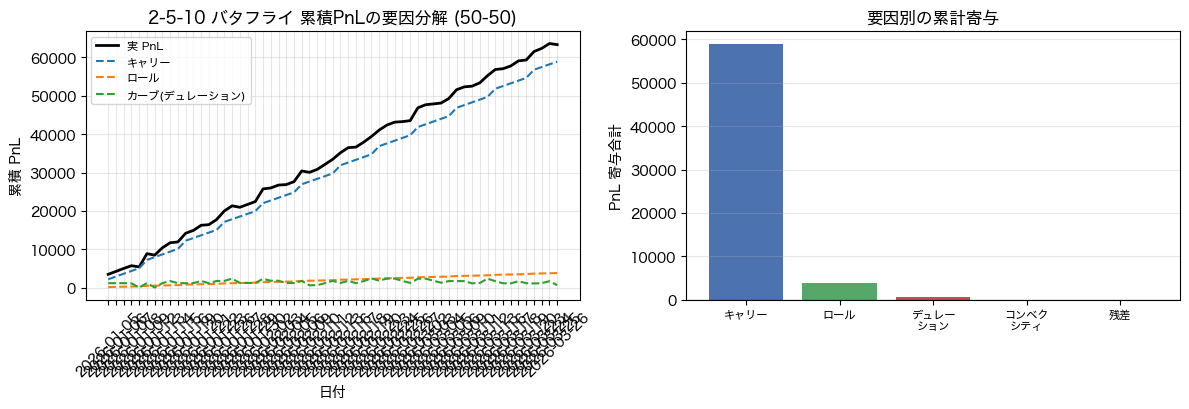

累積PnL図を _fig_butterfly_pnl.png に保存しました

要因別の累計寄与:
  carry     :   58905.5899
  roll      :    3779.9707
  duration  :     621.2125
  convexity :      21.3451
  residual  :       0.0129


In [8]:
cum = res["cum"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].plot(cum.index, cum["actual"], color="black", lw=2, label="実 PnL")
ax[0].plot(cum.index, cum["carry"], "--", label="キャリー")
ax[0].plot(cum.index, cum["roll"], "--", label="ロール")
ax[0].plot(cum.index, cum["duration"], "--", label="カーブ(デュレーション)")
ax[0].set_title("2-5-10 バタフライ 累積PnLの要因分解 (50-50)")
ax[0].set_xlabel("日付"); ax[0].set_ylabel("累積 PnL")
ax[0].legend(fontsize=8); ax[0].tick_params(axis="x", rotation=45)
ax[0].grid(alpha=0.3)

# 要因別の寄与（合計）
parts = res["daily"][["carry", "roll", "duration", "convexity", "residual"]].sum()
ax[1].bar(range(len(parts)), parts.values,
          color=["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#999999"])
ax[1].set_xticks(range(len(parts)))
ax[1].set_xticklabels(["キャリー", "ロール", "デュレー\nション", "コンベク\nシティ", "残差"], fontsize=8)
ax[1].axhline(0, color="black", lw=0.8)
ax[1].set_title("要因別の累計寄与")
ax[1].set_ylabel("PnL 寄与合計")
ax[1].grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()
print("累積PnL図を _fig_butterfly_pnl.png に保存しました")

print("\n要因別の累計寄与:")
for name, v in parts.items():
    print(f"  {name:10s}: {v:12.4f}")

## 演習

1. **3ウェイト方式のバタフライを比較せよ。** 50-50・リスクウェイト・PCA の
   3方式で 2-5-10 バタフライを構築し、(a) 合成のレベル変化 $(1,1,1)$ bp と
   スロープ変化 $(-1,0,1)$ bp を各建玉に当てたときの損益、(b) 同じバックテスト
   での累積 PnL・シャープ・説明率を比較せよ。どの方式がスロープをよく消すか、
   「何をニュートラル化するか」の理論と整合するかを述べよ。
2. **PnL分解でキャリー／ロール／カーブ変化の寄与を可視化せよ。** バックテスト
   の各日の PnL を要因分解し、キャリー・ロール・カーブ変化（デュレーション＋
   コンベクシティ）の**累計寄与**を積み上げ棒で示せ。累積実 PnL が主にどの
   要因で駆動されているかを一言で説明せよ。

解答例は `solutions/S9/sol_0902.py` にあります。

## 用語集

定義の正は `glossary/09_trading.md`。ここでは初出語の一行要約のみ示します。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| バタフライ | butterfly | カーブ3点のウィングとボディを反対に建て、曲率を取る取引 |
| DV01ニュートラル | DV01-neutral | 符号付きDV01の合計をゼロにし、平行移動に損益中立な状態 |
| リスクウェイト | risk weighting | ウィングのDV01を回帰ベータ比で配分し、スロープを消す重み付け |
| PnL分解 | PnL attribution | 損益をキャリー・ロール・カーブ変化・コンベクシティへ要因分解すること |